In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

%matplotlib inline

from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import make_scorer
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score, KFold
from sklearn.base import clone
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats
from scipy.stats import norm, skew  # for some statistics

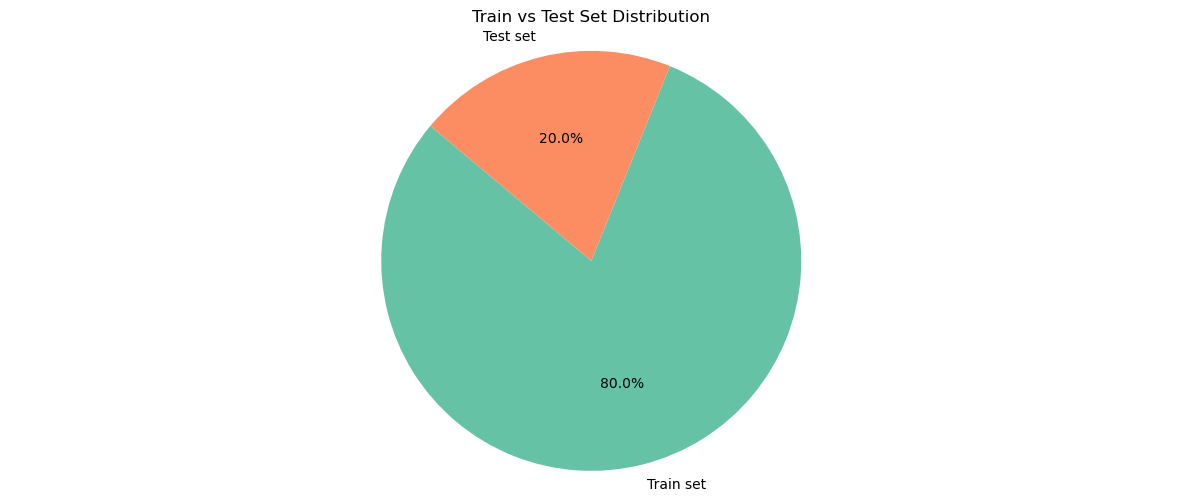

In [2]:
train = pd.read_csv("yield_df (3).csv")

# Split the dataset into training and test sets
train, test = train_test_split(train, test_size=0.2, random_state=42)
# Calculate the sizes of the training and test sets
sizes = [len(train), len(test)]
labels = ["Train set", "Test set"]

# Plot a pie chart
plt.figure(figsize=(15, 6))
plt.pie(sizes, labels=labels,  autopct='%1.1f%%', startangle=140, colors=['#66c2a5', '#fc8d62'])
plt.title("Train vs Test Set Distribution")
plt.axis("equal")  # Ensures the pie chart is circular
plt.show()

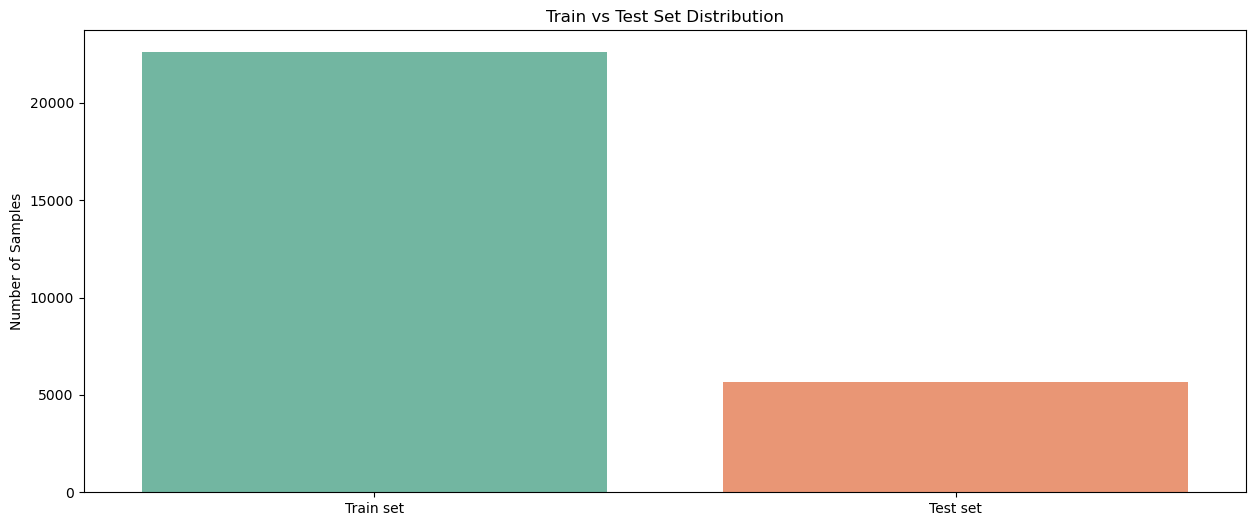

In [3]:
# Alternatively, plot a bar chart
plt.figure(figsize=(15,6))
sns.barplot(x=labels, y=sizes, hue=labels, palette=["#66c2a5", "#fc8d62"])
plt.title('Train vs Test Set Distribution')
plt.ylabel('Number of Samples')
plt.show();

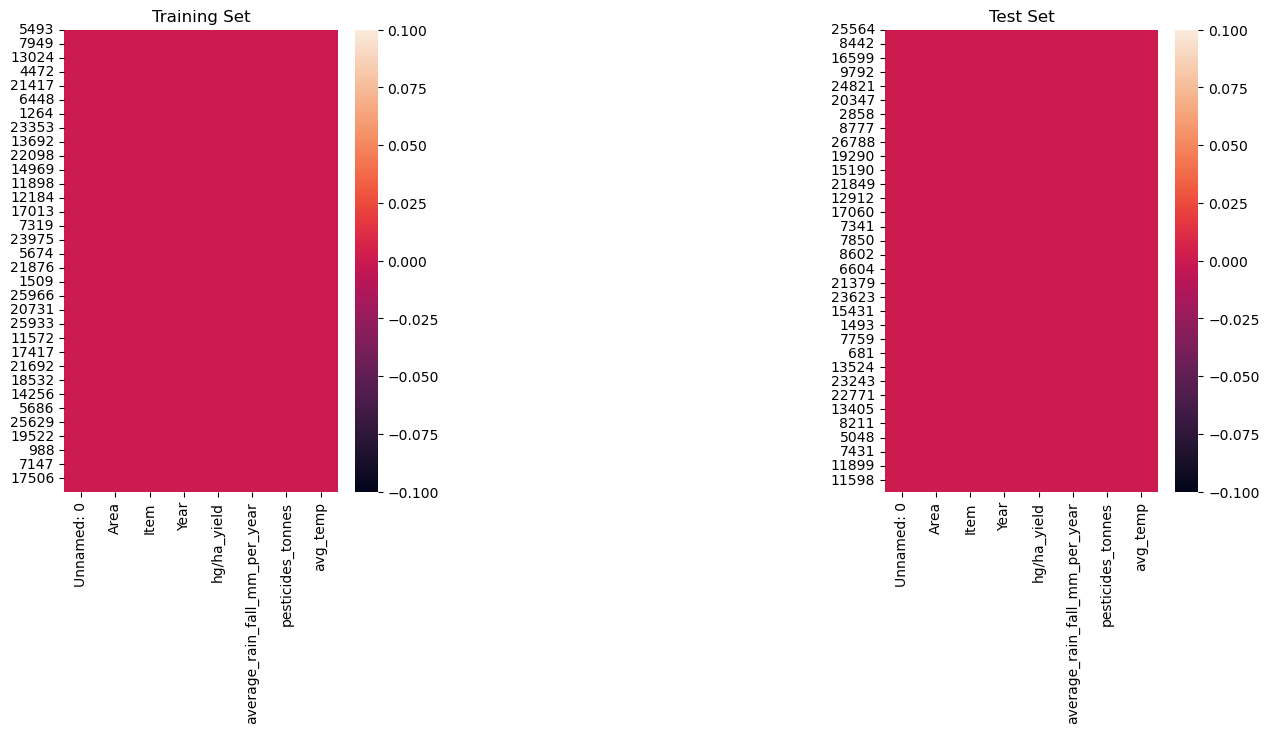

In [4]:
plt.figure(figsize = (15, 6))
plt.subplot(1, 3, 1)
plt.title("Training Set")
sns.heatmap(train.isnull())

plt.subplot(1, 3, 3)
plt.title("Test Set")
sns.heatmap(test.isnull())
plt.show()


In [5]:
print("train")
display(train.info())
print("test")
display(test.info())

train
<class 'pandas.core.frame.DataFrame'>
Index: 22593 entries, 5493 to 23654
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     22593 non-null  int64  
 1   Area                           22593 non-null  object 
 2   Item                           22593 non-null  object 
 3   Year                           22593 non-null  int64  
 4   hg/ha_yield                    22593 non-null  int64  
 5   average_rain_fall_mm_per_year  22593 non-null  float64
 6   pesticides_tonnes              22593 non-null  float64
 7   avg_temp                       22593 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.6+ MB


None

test
<class 'pandas.core.frame.DataFrame'>
Index: 5649 entries, 25564 to 3877
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     5649 non-null   int64  
 1   Area                           5649 non-null   object 
 2   Item                           5649 non-null   object 
 3   Year                           5649 non-null   int64  
 4   hg/ha_yield                    5649 non-null   int64  
 5   average_rain_fall_mm_per_year  5649 non-null   float64
 6   pesticides_tonnes              5649 non-null   float64
 7   avg_temp                       5649 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 397.2+ KB


None

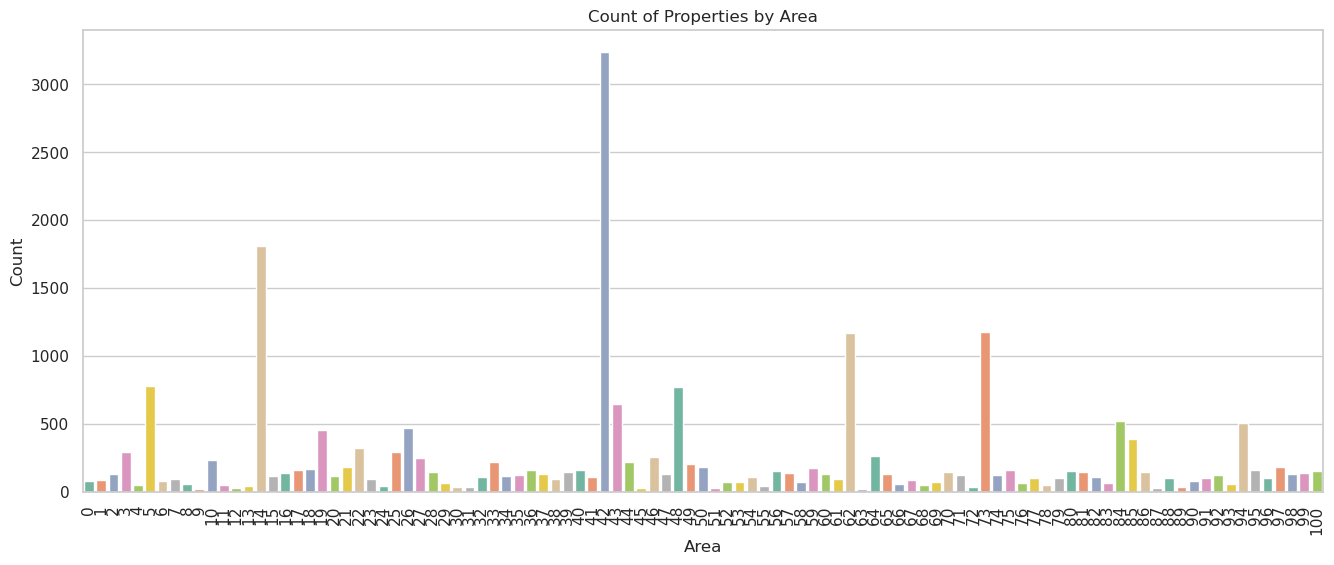

In [28]:
# Calculate the count of occurrences for each area
area_counts = train["Area"].value_counts()
# Plot the bar chart
plt.figure(figsize=(16, 6)) 
sns.barplot(x=area_counts.index, y=area_counts.values,  hue=area_counts.index, palette="Set2", legend=False)
plt.title('Count of Properties by Area')  # Set the title
plt.xlabel('Area')  # Label for x-axis
plt.ylabel('Count')  # Label for y-axis
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.show();  # Display the plot

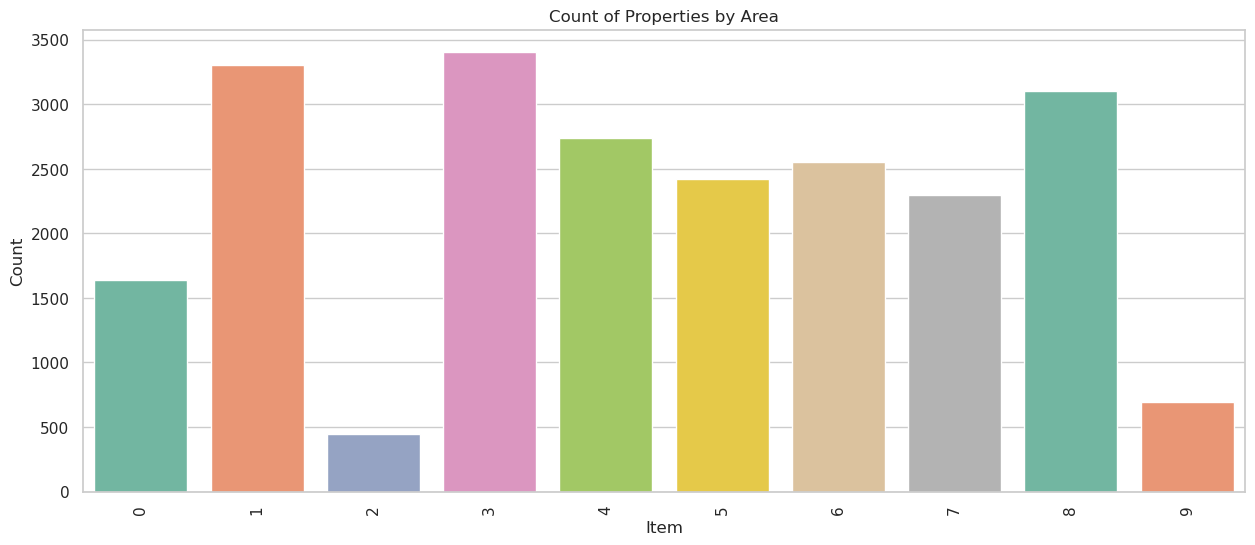

In [26]:
# Calculate the count of occurrences for each item
area_counts = train["Item"].value_counts()

# Plot the bar chart
plt.figure(figsize=(15, 6))

sns.barplot(
    x=area_counts.index,
    y=area_counts.values,
    hue=area_counts.index,
    palette="Set2",
    legend=False
)

plt.title('Count of Properties by Area')
plt.xlabel('Item')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.show()

In [8]:
train = train.reset_index(drop=True)
test =  test.reset_index(drop=True)

# Remove the target variable 'hg/ha_yield' from both train and test
train_target = train["hg/ha_yield"]
test_target = test["hg/ha_yield"]
train_data = train.drop(columns=["hg/ha_yield"])
test_data = test.drop(columns=["hg/ha_yield"])

# Combine train and test datasets (without the target)
combined = pd.concat([train_data, test_data], axis=0)

# Initialize the LabelEncoder
le = LabelEncoder()

# Loop through each column in the combined dataset and apply transformation to 'object' columns
for column in combined.columns:
    if combined[column].dtype == "object":
     combined[column] = le.fit_transform(combined[column])
    
# Split the combined data back into train and test sets
train_data_transformed = combined.iloc[:len(train_data), :]
test_data_transformed = combined.iloc[len(train_data):, :]

# Add the target column back to both transformed datasets
train_transformed = pd.concat([train_data_transformed, train_target.reset_index(drop=True)], axis=1)
test_transformed = pd.concat([test_data_transformed, test_target.reset_index(drop=True)], axis=1)

# Check the transformed datasets
train = train_transformed.copy()
test = test_transformed.copy()
display(train.head())
display(test.head())

,Unnamed: 0,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield
0,5493,18,5,2005,1604.0,829.59,25.36,13173
1,10969,42,6,1992,1083.0,70791.00,25.91,8947
2,2001,8,0,1997,1292.0,484.59,25.81,75317
3,22157,73,3,1997,494.0,16936.00,23.76,112295
4,311,2,7,2005,1010.0,40.00,24.41,46159


,Unnamed: 0,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield
0,25564,85,4,2008,636.0,40719.00,17.21,69220
1,18113,56,8,1996,1513.0,152.01,19.71,20000
2,25607,85,5,2010,636.0,39043.00,16.51,51206
3,6815,22,3,2007,3240.0,82439.06,27.45,166986
4,18144,56,7,2000,1513.0,130.46,19.65,56319


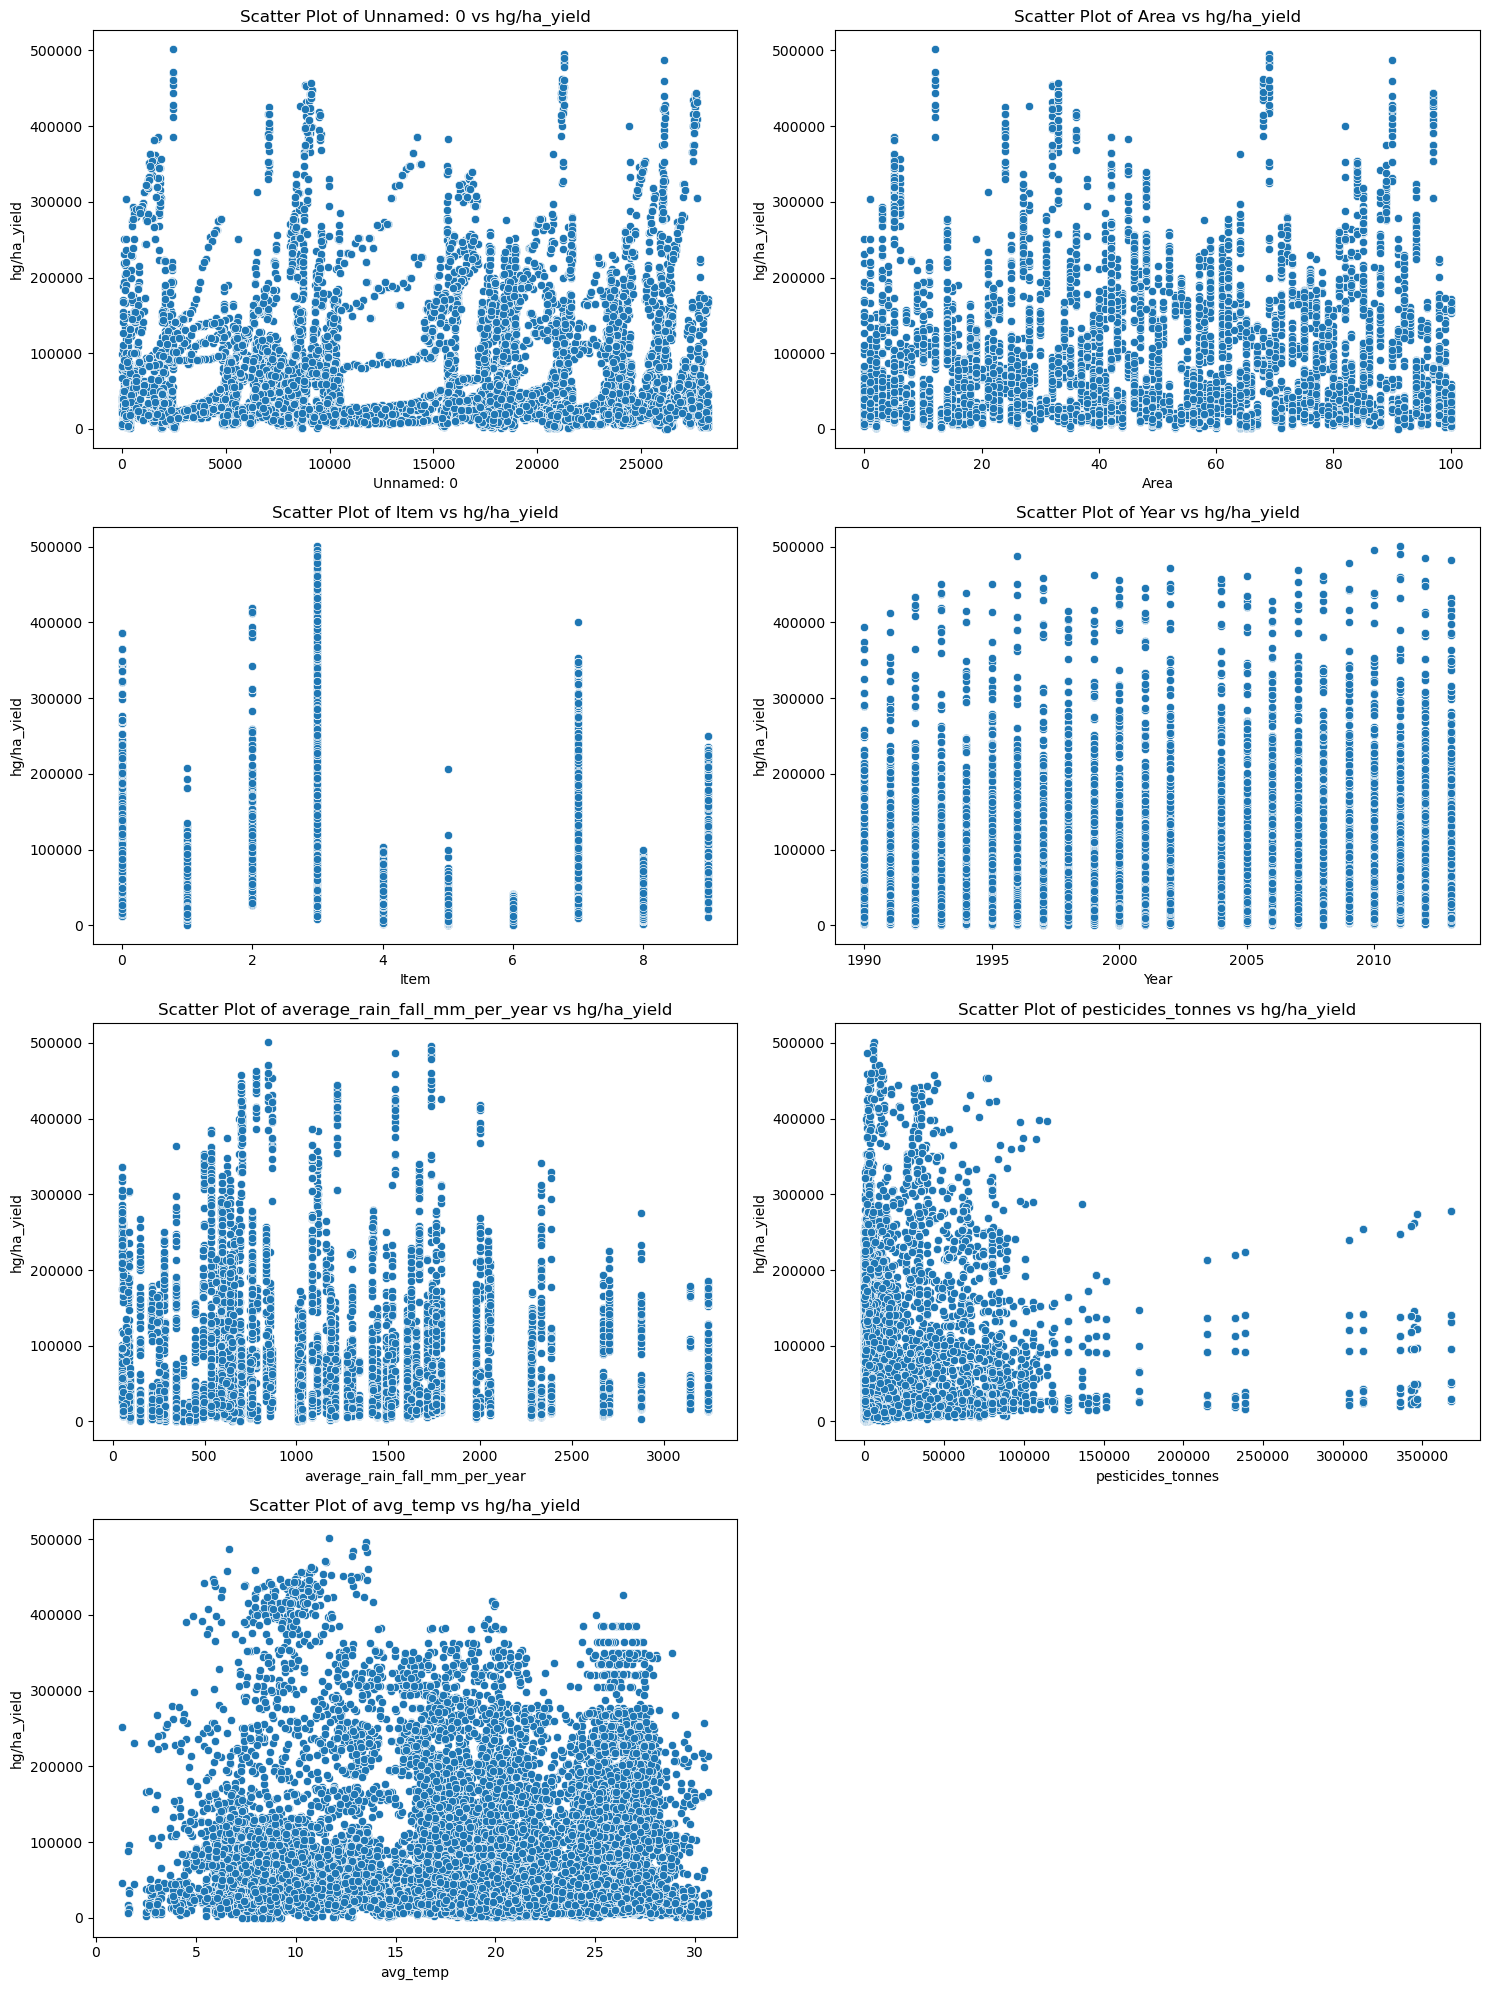

In [10]:
# Plot scatter plots for all columns
target_variable = "hg/ha_yield"
features = train.columns.drop(target_variable)

# Set up the layout of the plots
n_features = len(features)
n_cols = 2            # Number of columns per row
n_rows = (n_features + n_cols - 1) // n_cols   # Calculate the number of rows


plt.figure(figsize=(15, n_rows * 5))
           
for i, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(x=train[feature], y=train[target_variable])
    plt.title(f'Scatter Plot of {feature} vs {target_variable}')  # Set title for each plot
    plt.xlabel(feature)  # Label for x-axis
    plt.ylabel(target_variable)  # Label for y-axis

plt.tight_layout()  # Automatically adjust subplot spacing
plt.show()  # Display all plots     

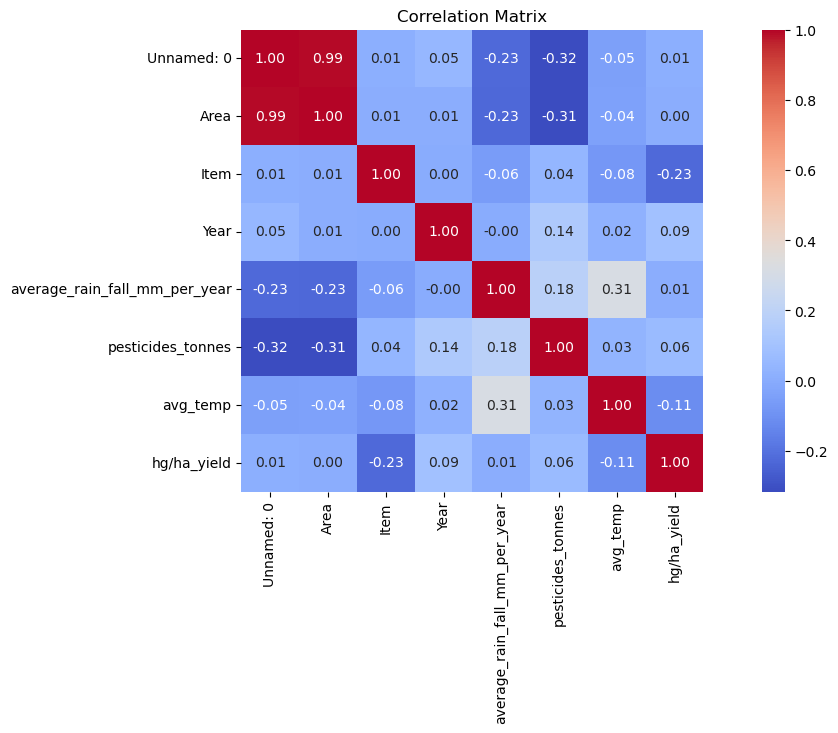

In [12]:
# Calculate the correlation matrix
correlation_matrix = train.corr()

# Display the correlation matrix
plt.figure(figsize=(15,6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True)
plt.title('Correlation Matrix')
plt.show()

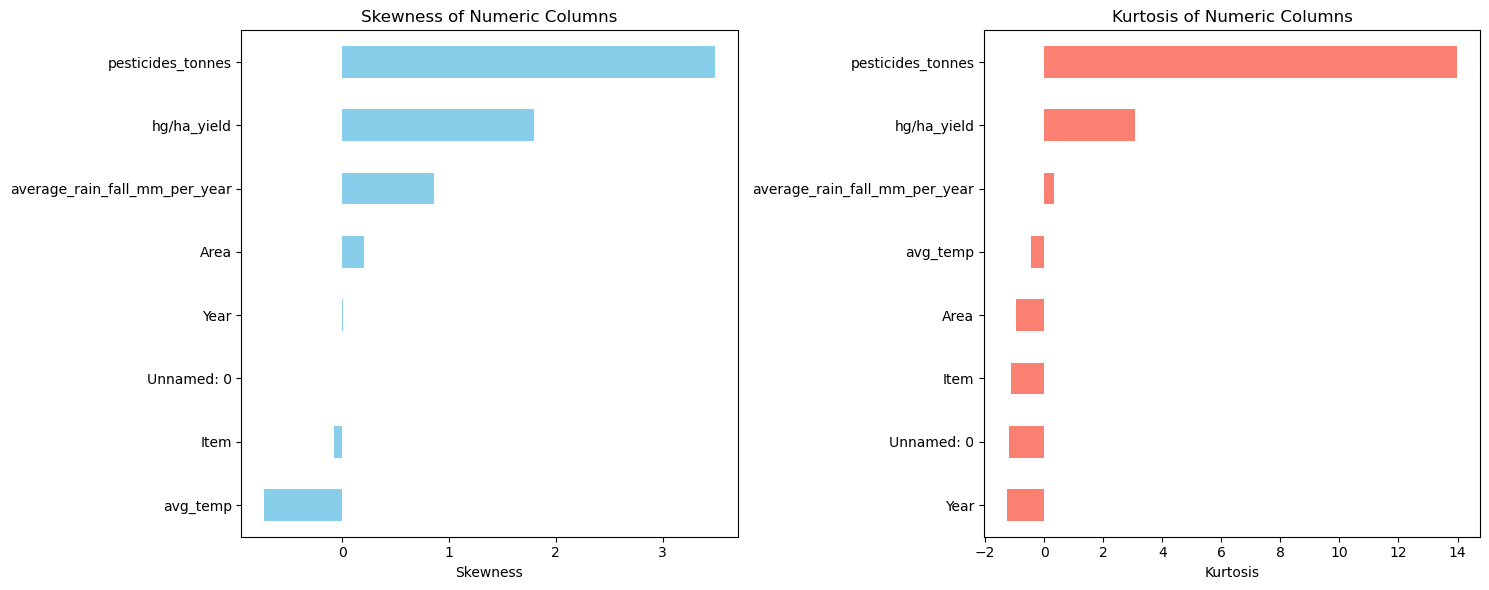

In [13]:
# Calculate Skewness and Kurtosis
numeric_df = train.select_dtypes(include=["number"])
skewness = numeric_df.skew()
kurtosis = numeric_df.kurtosis()

# Combine results into a DataFrame
result = pd.DataFrame({
    "Skewness":skewness,
    "Kurtosis":kurtosis
})

# Plot skewness
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
result["Skewness"].sort_values().plot(kind="barh", color="skyblue")
plt.title('Skewness of Numeric Columns')
plt.xlabel('Skewness')

# Plot Kurtosis
plt.subplot(1, 2, 2)
result['Kurtosis'].sort_values().plot(kind='barh', color='salmon')
plt.title('Kurtosis of Numeric Columns')
plt.xlabel('Kurtosis')

plt.tight_layout()
plt.show()

In [14]:
X= train.drop(columns=["hg/ha_yield"],axis=1)
y= train["hg/ha_yield"]

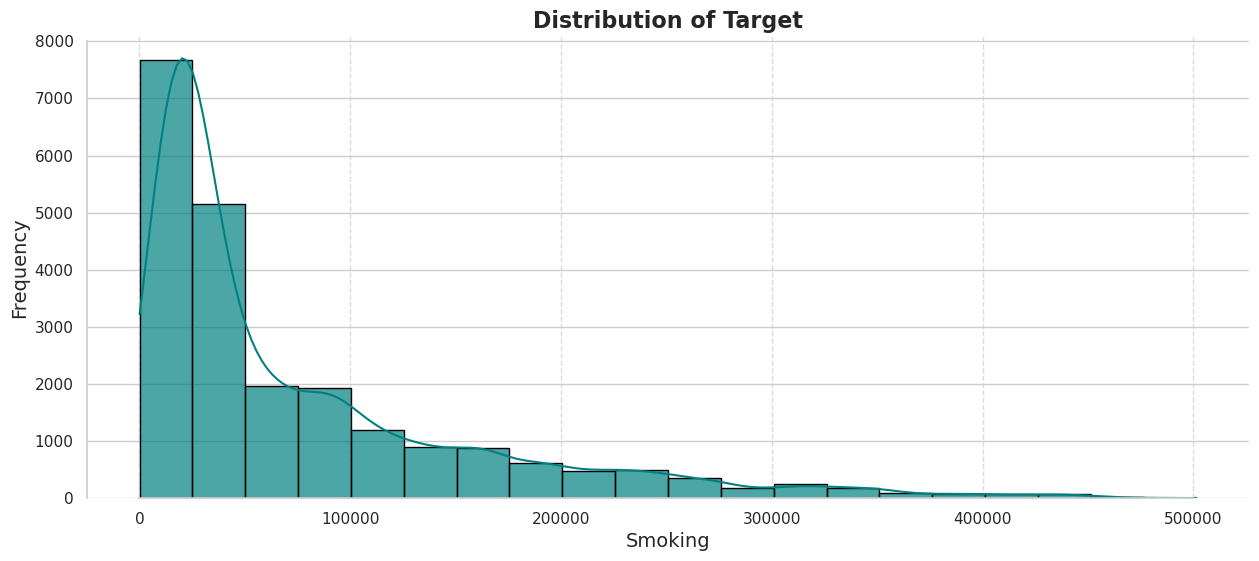

Skewness: 1.793258
Kurtosis: 3.066628


In [15]:
# Target distribution
# Set the style for the plots
sns.set(style="whitegrid")
sns.set_palette("pastel")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(15, 6))

# Plot the histogram with a KDE curve
sns.histplot(y, kde=True, color="teal", bins=20, alpha=0.7, edgecolor="black")

# Set the title and axis labels
ax.set_title('Distribution of Target', fontsize=16, weight='bold')  # Title with bold font
ax.set_xlabel('Smoking', fontsize=14)  # X-axis label
ax.set_ylabel('Frequency', fontsize=14)  # Y-axis label

# Add grid lines to the x-axis
ax.xaxis.grid(True, linestyle='--', alpha=0.7)  # Dashed grid lines with some transparency

# Remove the top and right spines (borders) of the plot
sns.despine(trim=True)

# Display the plot
plt.show()

# Calculate and print skewness and kurtosis
print("Skewness: %f" % y.skew())  # Measure of asymmetry in the data
print("Kurtosis: %f" % y.kurt())  # Measure of the tails' heaviness in the data
